<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/exploration_cw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PySpark initiation

In [27]:
!pip install pyspark

from pyspark.sql import SparkSession

spark_sesh = SparkSession.builder \
  .getOrCreate()

print(spark_sesh)

#
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Read in the data

In [28]:
import pandas as pd

data = pd.read_csv(r"/content/listings(5).csv.gz")
df = pd.DataFrame(data)
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,11156,https://www.airbnb.com/rooms/11156,20250912034438,2025-09-12,previous scrape,An Oasis in the City,Very central to the city which can be reached ...,"It is very close to everything and everywhere,...",https://a0.muscache.com/pictures/2797669/17895...,40855,...,4.76,4.82,4.71,NaN,f,1,0,1,0,1.01
1,15253,https://www.airbnb.com/rooms/15253,20250912034438,2025-09-12,previous scrape,Unique Designer Rooftop Apartment in City Loca...,You will be staying in a unique apartment on t...,The location is really central and there is nu...,https://a0.muscache.com/pictures/a41641fb-0e5a...,59850,...,4.75,4.76,4.57,PID-STRA-24061-7,t,1,0,1,0,3.83
2,44545,https://www.airbnb.com/rooms/44545,20250912034438,2025-09-12,previous scrape,Sunny Darlinghurst Warehouse Apartment,Sunny warehouse/loft apartment in the heart of...,Darlinghurst is home to some of Sydney's best ...,https://a0.muscache.com/pictures/a88d8e14-4f63...,112237,...,4.96,4.94,4.80,PID-STRA-74219,f,1,1,0,0,0.47


View columns. Ideas:
*   List item
*   List item



In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17730 entries, 0 to 17729
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            17730 non-null  int64  
 1   listing_url                                   17730 non-null  object 
 2   scrape_id                                     17730 non-null  int64  
 3   last_scraped                                  17730 non-null  object 
 4   source                                        17730 non-null  object 
 5   name                                          17730 non-null  object 
 6   description                                   17452 non-null  object 
 7   neighborhood_overview                         8113 non-null   object 
 8   picture_url                                   17730 non-null  object 
 9   host_id                                       17730 non-null 

Values

<Axes: >

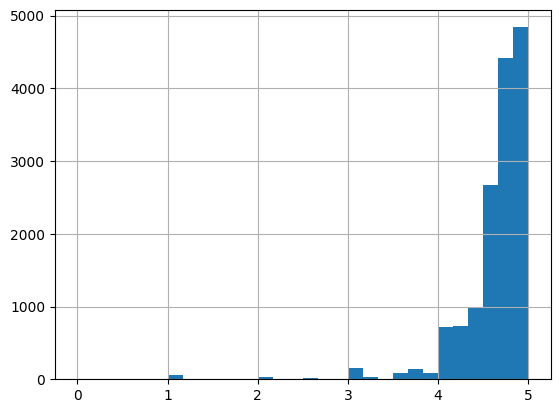

In [30]:
df['review_scores_value'].hist(bins=30)

What is the review accuracy column: assumed to be continuous rating. (more context)

In [31]:
df['review_scores_value']

,review_scores_value
0,4.71
1,4.57
2,4.80
3,4.73
4,4.93
...,...
17725,5.00
17726,NaN
17727,4.00
17728,4.00




---


Description

In [32]:
df['description'][0:10]

,description
0,Very central to the city which can be reached ...
1,You will be staying in a unique apartment on t...
2,Sunny warehouse/loft apartment in the heart of...
3,"An open plan apartment, adjacent to a spacious..."
4,"Hello Everyone,<br /><br />We have a quiet are..."
5,"Spacious, airy, fully furnished apartment in C..."
6,"Spacious, bright and airy and surrounded by gr..."
7,Spacious self-contained bayside apartment in q...
8,Fully furnished 2-bedroom art deco garden apar...
9,Our apartment is n art deco building. Large 2 ...


Setting up a dataframe

In [33]:
#sentiment dataframe: sdf
sdf = df[['description', 'review_scores_value']]
sdf.head()

,description,review_scores_value
0,Very central to the city which can be reached ...,4.71
1,You will be staying in a unique apartment on t...,4.57
2,Sunny warehouse/loft apartment in the heart of...,4.80
3,"An open plan apartment, adjacent to a spacious...",4.73
4,"Hello Everyone,<br /><br />We have a quiet are...",4.93


Cleaning

In [34]:
import re

def clean_func(string):
  #ensure text is in fact strings
  text = str(string)
  #remove tags
  cleaner_text = re.sub('<[^<]+?>', '', text)
  full_clean_text = re.sub(r'[^a-zA-Z0-9\s]', '', cleaner_text)
  return full_clean_text

sdf['clean_descs'] = sdf['description'].apply(clean_func)
sdf['clean_descs'].head(3)



/tmp/ipykernel_396/245240405.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sdf['clean_descs'] = sdf['description'].apply(clean_func)


,clean_descs
0,Very central to the city which can be reached ...
1,You will be staying in a unique apartment on t...
2,Sunny warehouseloft apartment in the heart of ...


DataFrame to PySpark

In [36]:
#first to a csv: cleaned_sydney_listings.csv
sdf.to_csv('/content/drive/MyDrive/cleaned_sydney_listings', index=False)

Read shorter file back in

In [41]:
full_spark_df = spark_sesh.read.option("header",True)\
  .option("multiLine",True)\
  .csv("drive/MyDrive/cleaned_sydney_listings")

Observation and Preparation

In [43]:
#full_spark_df.show(10)

#drop description column
spark_df = full_spark_df.drop('description')
#rename cleaned description to desc
spark_df = spark_df.withColumnRenamed(spark_df.columns[1],
                                      'description')
#add an

+-------------------+--------------------+
|review_scores_value|         description|
+-------------------+--------------------+
|               4.71|Very central to t...|
|               4.57|You will be stayi...|
|                4.8|Sunny warehouselo...|
|               4.73|An open plan apar...|
|               4.93|Hello EveryoneWe ...|
|               4.33|Spacious airy ful...|
|                5.0|Spacious bright a...|
|               4.93|Spacious selfcont...|
|               4.44|Fully furnished 2...|
|               4.56|Our apartment is ...|
+-------------------+--------------------+
only showing top 10 rows


Sentiment Analysis

Keyword identification